In [4]:
import json
from collections import Counter

files = {
    'legitimate': '../data/legitimate_dataset.json',
    'malicious': '../data/malicious_dataset.json'
}

for name, path in files.items():
    print(f"{'='*50}")
    print(f"DATASET: {name}")
    print(f"{'='*50}")

    with open(path, encoding='utf-8') as f:
        data = json.load(f)

    print(f"Total entries: {len(data)}")
    print(f"Type: {type(data)}")
    print(f"\nFirst 3 entries:")
    for entry in data[:3]:
        print(f"  {entry}")

    print(f"\nEntry length stats:")
    lengths = [len(entry) for entry in data]
    print(f"  min: {min(lengths)}")
    print(f"  max: {max(lengths)}")
    print(f"  avg: {sum(lengths)/len(lengths):.1f}")

    print(f"\nTop 10 params:")
    from urllib.parse import parse_qs
    params = []
    for entry in data:
        parsed = parse_qs(entry, keep_blank_values=True)
        params.extend(parsed.keys())
    for param, count in Counter(params).most_common(10):
        print(f"  {param}: {count}")

    print()

DATASET: legitimate
Total entries: 508530
Type: <class 'list'>

First 3 entries:
  source%5Baction%5D=show&source%5Bapp%5D=Shopify&source%5Bcontroller%5D=checkouts%2Fweb%2Fcheckouts&source%5Bsection%5D=checkout&source%5Bshop_id%5D=47291236517&source%5Buuid%5D=df2efbe7-0998-48b7-a10b-c19be9410df6
  v=1645527473
  origin=onetag&domain=365mashbir.co.il&sn=ChromeSyncframe&so=3&topUrl=365mashbir.co.il&bundle=ldVXDl9hS0VDdENtdzZsT1V1aHVWVWdzeDhhSkRrekRKcUtKQUI4cyUyQjk5ZkZQZ1gySjBvNTBabHdQUmJIUXAyTmolMkJsS01Hb09OT1ZXTTdzNUNFOUZMdExuRWhzWEppeU9XYW5BUWFpU3hvcmQwdVdMTHhPYVV3YWxTWiUyRnFqQ3VrNmxkbkdjakpLbG5iaUJJd01oZWl5cGFkVCUyRjl4Q2tiMHREVDg3QTJRbmJqQlFaYyUzRA&cw=1&lsw=1&topicsavail=0&fledgeavail=0

Entry length stats:
  min: 1
  max: 31673
  avg: 360.3

Top 10 params:
  v: 105663
  gtm: 62807
  url: 58673
  id: 52069
  fmt: 50249
  t: 50241
  dl: 48797
  cv: 48541
  guid: 47011
  frm: 46011

DATASET: malicious
Total entries: 30544
Type: <class 'list'>

First 3 entries:
  p=%00%27%27%20UNION%20SE

In [8]:
import pandas as pd
from urllib.parse import unquote, parse_qs

with open('../data/legitimate_dataset.json', encoding='utf-8') as f:
    legit_raw = json.load(f)

with open('../data/malicious_dataset.json', encoding='utf-8') as f:
    malicious_raw = json.load(f)

legit_rows = []
for entry in legit_raw:
    parsed = parse_qs(entry, keep_blank_values=True)
    for k, v in parsed.items():
        legit_rows.append({'param': k, 'value': unquote(v[0])})

df_legit = pd.DataFrame(legit_rows)
df_legit['label'] = 0

df_malicious = pd.DataFrame({
    'param': 'p',
    'value': [unquote(parse_qs(e, keep_blank_values=True).get('p', [e])[0]) for e in malicious_raw]
})
df_malicious['label'] = 1

df_legit.to_csv('../data/legitimate_clean.csv', index=False, encoding='utf-8')
df_malicious.to_csv('../data/malicious_clean.csv', index=False, encoding='utf-8')

print("Legitimate shape:", df_legit.shape)
print(df_legit.head(5))
print()
print("Malicious shape:", df_malicious.shape)
print(df_malicious.head(5))

Legitimate shape: (5131819, 3)
                param                    value  label
0      source[action]                     show      0
1         source[app]                  Shopify      0
2  source[controller]  checkouts/web/checkouts      0
3     source[section]                 checkout      0
4     source[shop_id]              47291236517      0

Malicious shape: (30544, 3)
  param                                              value  label
0     p   '' UNION SELECT password FROM Users WHERE use...      1
1     p   ' UNION SELECT password FROM Users WHERE user...      1
2     p                    \n\r+select+user+from+dual+\n\r      1
3     p  \nselect 0x00, 0x41 like/*!31337table_name*/,3...      1
4     p  \nselect 0x00, 0x41 not like/*!00000table_name...      1


=== SHAPE ===
Legitimate: (5131819, 3)
Malicious:  (30544, 3)

=== NULLS ===
Legitimate nulls: {'param': 30, 'value': 187003, 'label': 0}
Malicious nulls:  {'param': 0, 'value': 2, 'label': 0}

=== VALUE LENGTH STATS ===
Legitimate value length:
count    5.131819e+06
mean     2.385505e+01
std      1.259013e+02
min      1.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      1.500000e+01
max      1.019800e+04
Name: value_len, dtype: float64

Malicious value length:
count    30544.000000
mean       118.284115
std         87.290696
min          1.000000
25%         54.000000
50%         95.000000
75%        158.000000
max       2503.000000
Name: value_len, dtype: float64

=== TOP 15 PARAMS (legitimate) ===
param
v        105663
gtm       62807
url       58673
id        52069
fmt       50249
t         50241
dl        48797
cv        48541
guid      47011
frm       46011
u_h       45901
u_w       45901
u_his     45901
u_aw      45871
u_cd      45871
Name: count, dtype: int64

=== 

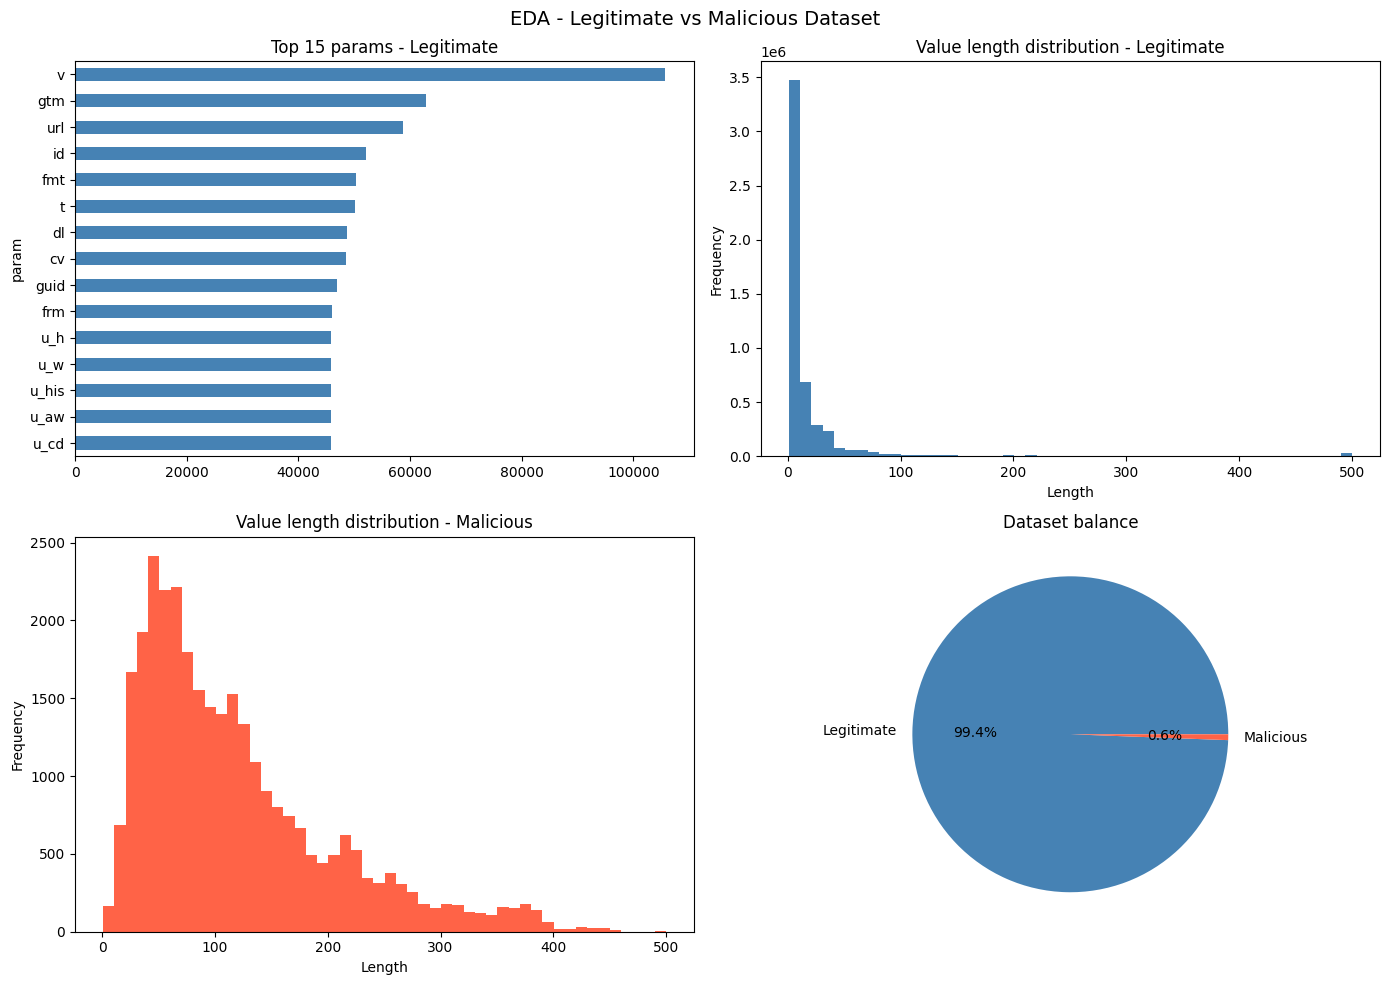


Plot saved to ./data/eda_overview.png


In [10]:
import matplotlib.pyplot as plt

df_legit = pd.read_csv('../data/legitimate_clean.csv', encoding='utf-8')
df_malicious = pd.read_csv('../data/malicious_clean.csv', encoding='utf-8')

print("=== SHAPE ===")
print(f"Legitimate: {df_legit.shape}")
print(f"Malicious:  {df_malicious.shape}")

print("\n=== NULLS ===")
print("Legitimate nulls:", df_legit.isnull().sum().to_dict())
print("Malicious nulls: ", df_malicious.isnull().sum().to_dict())

print("\n=== VALUE LENGTH STATS ===")
df_legit['value_len'] = df_legit['value'].astype(str).str.len()
df_malicious['value_len'] = df_malicious['value'].astype(str).str.len()
print("Legitimate value length:")
print(df_legit['value_len'].describe())
print("\nMalicious value length:")
print(df_malicious['value_len'].describe())

print("\n=== TOP 15 PARAMS (legitimate) ===")
print(df_legit['param'].value_counts().head(15))

print("\n=== UNIQUE PARAMS ===")
print(f"Legitimate unique params: {df_legit['param'].nunique()}")
print(f"Malicious unique params:  {df_malicious['param'].nunique()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA - Legitimate vs Malicious Dataset', fontsize=14)

df_legit['param'].value_counts().head(15).plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Top 15 params - Legitimate')
axes[0, 0].invert_yaxis()

df_legit['value_len'].clip(upper=500).plot(kind='hist', bins=50, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Value length distribution - Legitimate')
axes[0, 1].set_xlabel('Length')

df_malicious['value_len'].clip(upper=500).plot(kind='hist', bins=50, ax=axes[1, 0], color='tomato')
axes[1, 0].set_title('Value length distribution - Malicious')
axes[1, 0].set_xlabel('Length')

sizes = [len(df_legit), len(df_malicious)]
axes[1, 1].pie(sizes, labels=['Legitimate', 'Malicious'], autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1, 1].set_title('Dataset balance')

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150)
plt.show()

print("\nPlot saved to ./data/eda_overview.png")